# 04 – Baseline Modelling

### Notebook Summary - Baseline Modeling (Kepler → TESS)

This notebook builds an initial predictive model to explore the underlying structure in the **Kepler** and **TESS** datasets.  
We began by applying the reusable `filter_physical()` function to ensure all samples lie within physically plausible ranges.  

We then constructed a **binary classification baseline** using logistic regression, aiming to predict planet disposition.  
Before training, selected features were log-transformed to stabilize their scale (e.g., orbital period, insolation flux).  

The **naïve Kepler→TESS transfer model** achieved limited performance, indicating poor generalization across missions.  
To address this, we applied **covariate reweighting**, adjusting Kepler’s feature distribution toward TESS’s domain.  
However, the reweighted model performed even worse — a meaningful finding.  

This suggests that simple reweighting does not compensate for deep distributional differences between missions:  
the logistic model trained on Kepler captures patterns that **do not transfer** to TESS due to feature variance and label imbalance.  

In short:  
> “The model learned Kepler’s observational bias, not a mission-invariant physical relationship.”

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# project import path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing import filter_physical

In [2]:
PROCESSED = PROJECT_ROOT / "data" / "processed"
kepler = pd.read_csv(PROCESSED / "kepler_clean.csv")
tess   = pd.read_csv(PROCESSED / "tess_clean.csv")

kepler_phys = filter_physical(kepler)
tess_phys   = filter_physical(tess)

kepler_phys.shape, tess_phys.shape

((7365, 16), (5982, 17))

In [3]:
# Build aligned binary target
def build_binary_y(df: pd.DataFrame, mission: str) -> pd.Series:
    if mission.lower() == "tess":
        # TESS has disposition_aligned 
        disp = df.get("disposition_aligned")
    else:
        # Kepler disposition already similar (CONFIRMED / CANDIDATE / FALSE POSITIVE)
        disp = df.get("disposition")
    return (disp == "CONFIRMED").astype(int)

# Feature set (shared across missions)
FEATURES = [
    "orbital_period", "planet_radius",
    "transit_duration", "transit_depth",
    "equilibrium_temp", "insolation_flux",
    "stellar_teff", "stellar_logg", "stellar_radius"
]

# Minimal preprocessing: drop NA rows for selected features + label
def prep_dataset(df: pd.DataFrame, mission: str):
    cols = FEATURES.copy()
    X = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
    # align y to X's index
    y = build_binary_y(df.loc[X.index], mission)
    # keep only rows where y is not NA (e.g., some TESS may be unlabeled)
    mask = y.notna()
    return X.loc[mask], y.loc[mask].astype(int)

XK, yK = prep_dataset(kepler_phys, "kepler")
XT, yT = prep_dataset(tess_phys, "tess")

XK.shape, yK.mean(), XT.shape, yT.mean()

((7365, 9),
 np.float64(0.3712152070604209),
 (5982, 9),
 np.float64(0.11033099297893681))

In [4]:
def add_log_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    for c in ["orbital_period","planet_radius","transit_duration","transit_depth","insolation_flux"]:
        if c in X.columns:
            # Skip if already logged column exists
            if f"log_{c}" in X.columns:
                continue
            vals = np.clip(X[c].values, 1e-12, None)
            # Skip if data already look like log scale (heuristic)
            if np.nanmax(vals) < 50 and np.nanmin(vals) > -10:
                # probably already logged (range too small for physical)
                continue
            X[f"log_{c}"] = np.log10(vals)
    return X

XKf = add_log_features(XK)
XTf = add_log_features(XT)
feat_cols = XKf.columns  # use same order for both

In [5]:
XKf

,orbital_period,planet_radius,transit_duration,transit_depth,equilibrium_temp,insolation_flux,stellar_teff,stellar_logg,stellar_radius,log_orbital_period,log_transit_depth,log_insolation_flux
1,272.542881,2.35,3.02460,807.2,255.0,1.00,5677.0,4.563,0.828,2.435435,2.906981,0.000000
2,1.756471,0.69,2.53800,69.5,1405.0,924.14,5813.0,4.561,0.833,0.244641,1.841985,2.965738
3,384.356448,3.03,3.87200,715.7,255.0,1.00,5903.0,4.445,0.994,2.584734,2.854731,0.000000
4,378.654840,1.53,11.30000,247.8,258.0,1.04,6000.0,4.463,0.970,2.578244,2.394101,0.017033
6,0.933761,0.57,3.02700,27.3,2064.0,4286.78,6292.0,4.426,1.078,-0.029764,1.436163,3.632131
...,...,...,...,...,...,...,...,...,...,...,...,...
9559,4.780328,7.14,2.02530,960.8,1441.0,1020.05,5937.0,4.012,1.787,0.679458,2.982633,3.008621
9560,3.849372,12.94,2.63200,1298.6,2034.0,4055.29,6244.0,3.657,2.992,0.585390,3.113475,3.608022
9561,4.887803,4.82,2.36255,4315.8,800.0,96.67,4778.0,4.591,0.763,0.689114,3.635061,1.985292
9562,2.204735,16.10,3.88864,6674.7,2048.0,4148.92,6440.0,4.019,1.952,0.343356,3.824432,3.617935


In [6]:
# Train on Kepler, test on TESS (labeled subset), no domain correction
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight=None, random_state=0)
)
pipe.fit(XKf[feat_cols], yK)

# Evaluate on TESS labeled subset
proba_T = pipe.predict_proba(XTf[feat_cols])[:,1]
pred_T  = (proba_T >= 0.5).astype(int)

print("Naïve Kepler→TESS baseline")
print(classification_report(yT, pred_T, digits=3))
print("ROC AUC:", roc_auc_score(yT, proba_T))

Naïve Kepler→TESS baseline
              precision    recall  f1-score   support

           0      0.940     0.586     0.722      5322
           1      0.173     0.700     0.278       660

    accuracy                          0.598      5982
   macro avg      0.557     0.643     0.500      5982
weighted avg      0.856     0.598     0.673      5982

ROC AUC: 0.6913628961543279


In [7]:
# Build pooled set for mission classification
XKf_m = XKf[feat_cols].copy();  y_mK = np.zeros(len(XKf_m), dtype=int)
XTf_m = XTf[feat_cols].copy();  y_mT = np.ones(len(XTf_m),  dtype=int)

Xm = pd.concat([XKf_m, XTf_m], axis=0)
ym = np.concatenate([y_mK, y_mT])

# Mission classifier: Kepler vs TESS (logistic regression is enough)
mission_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=0)
)
mission_clf.fit(Xm, ym)

# Importance weights for Kepler: w = p(TESS|x) / (1 - p(TESS|x))
p_tess_on_kepler = mission_clf.predict_proba(XKf_m)[:,1]
wK = p_tess_on_kepler / np.clip(1 - p_tess_on_kepler, 1e-6, None)
# clip extreme weights for stability
wK = np.clip(wK, 0.1, 50.0)

# Train disposition model on Kepler with weights
pipe_w = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight=None, random_state=0)
)
pipe_w.fit(XKf[feat_cols], yK, logisticregression__sample_weight=wK)

# Evaluate on TESS labeled subset
proba_T_w = pipe_w.predict_proba(XTf[feat_cols])[:,1]
pred_T_w  = (proba_T_w >= 0.5).astype(int)

print("Weighted Kepler→TESS (covariate shift corrected)")
print(classification_report(yT, pred_T_w, digits=3))
print("ROC AUC:", roc_auc_score(yT, proba_T_w))

Weighted Kepler→TESS (covariate shift corrected)
              precision    recall  f1-score   support

           0      0.934     0.552     0.694      5322
           1      0.159     0.685     0.259       660

    accuracy                          0.567      5982
   macro avg      0.547     0.619     0.476      5982
weighted avg      0.848     0.567     0.646      5982

ROC AUC: 0.6550507897463929


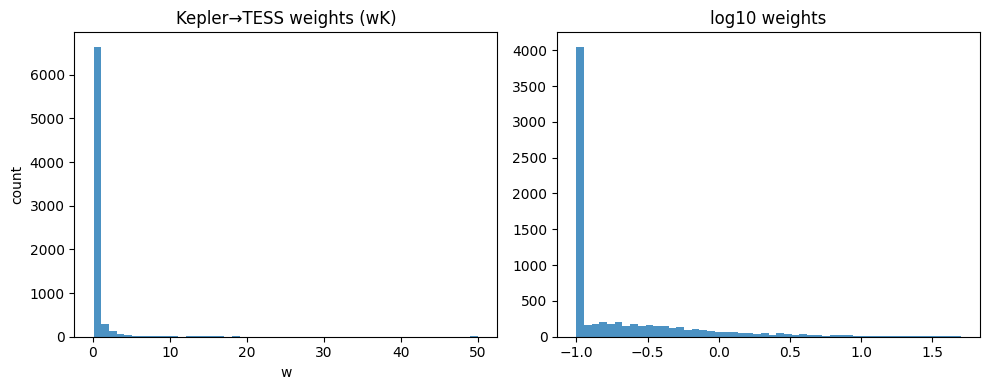

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(wK, bins=50, alpha=0.8)
ax[0].set_title("Kepler→TESS weights (wK)")
ax[0].set_xlabel("w"); ax[0].set_ylabel("count")
ax[1].hist(np.log10(np.clip(wK,1e-6,None)), bins=50, alpha=0.8)
ax[1].set_title("log10 weights")
plt.tight_layout(); plt.show()

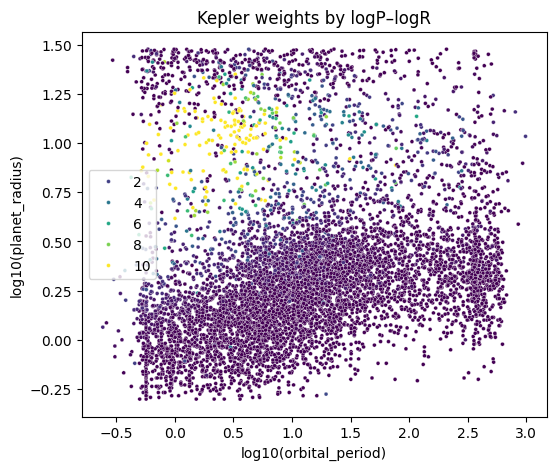

In [9]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=np.log10(XKf["orbital_period"]),
    y=np.log10(XKf["planet_radius"]),
    hue=np.clip(wK,0,10),
    palette="viridis", s=8
)
plt.title("Kepler weights by logP–logR")
plt.xlabel("log10(orbital_period)"); plt.ylabel("log10(planet_radius)")
plt.show()

In [10]:
auc_mission = roc_auc_score(ym, mission_clf.predict_proba(Xm)[:,1])
print("Mission classifier ROC AUC:", auc_mission)

Mission classifier ROC AUC: 0.9353509044898898


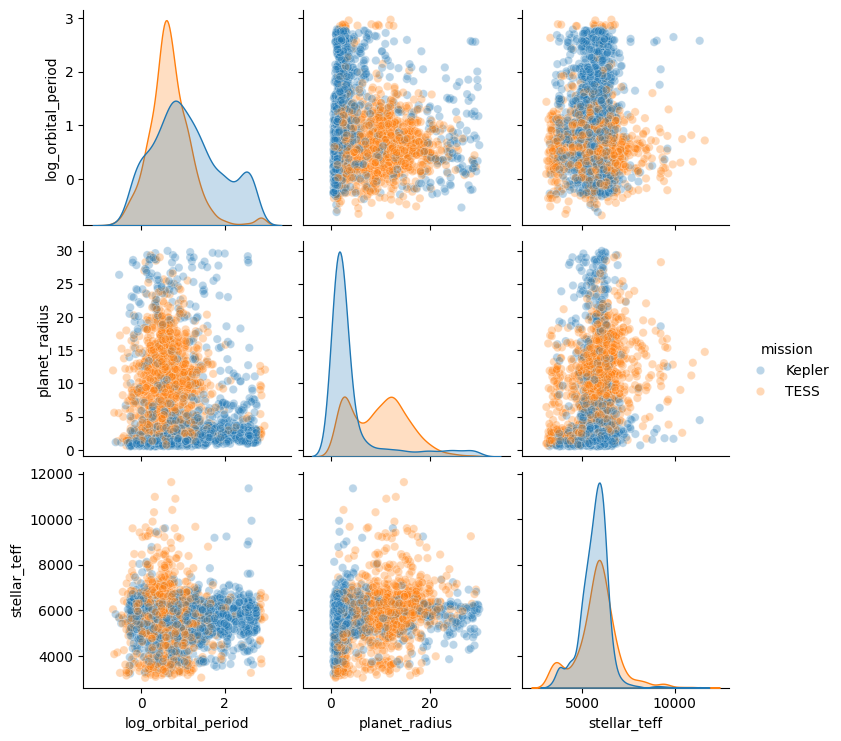

In [11]:
dfm = pd.concat([
    XKf.assign(mission="Kepler"),
    XTf.assign(mission="TESS")
])

sns.pairplot(dfm.sample(3000), vars=["log_orbital_period","planet_radius","stellar_teff"], hue="mission", plot_kws=dict(alpha=0.3))

### Next Steps

- Investigate **domain adaptation** techniques (e.g., feature alignment, transfer learning) to reduce mission bias.  
- Explore **mixed training strategies**, combining reweighted subsets from both Kepler and TESS for shared representation learning.  
- Evaluate **mission-invariant features** - those most stable across observational domains - to improve generalization.  
- Use more expressive models (e.g., tree ensembles) to test whether nonlinear boundaries capture cross-mission relationships.

---

💡 *This notebook concludes the baseline phase. The next modeling stage will focus on adapting to the TESS domain while preserving interpretability and physical consistency.*